# VizEx — validation analysis

Do the features recovered from a participant's recreation track the features of
the target image they were shown? Validation trials only (`stimulus_type == IMAGE`,
condition codes A00–C14).

Model per feature: `recreation ~ target`, random intercept per participant.
The slope answers whether recreations track targets.

Produces five small square figures (one per feature), a separate key, and a
paper-ready results table.

Requires `010_build_index` and `015_feature_extraction` to have been run first.

In [1]:
## imports

import io
import re
import textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from matplotlib.lines import Line2D
import statsmodels.formula.api as smf
from statsmodels.stats.multitest import multipletests

In [2]:
## paths and features

PROJECT_PATH = Path().resolve().parent
TABLES_PATH = PROJECT_PATH / "015_tables"
VIZ_PATH = PROJECT_PATH / "020_visualizations"
VIZ_PATH.mkdir(parents=True, exist_ok=True)

TRIALS_FEATURES_CSV = TABLES_PATH / "vizex_features.csv"
TARGETS_FEATURES_CSV = TABLES_PATH / "vizex_targets_features.csv"

# Column name -> label used in figure titles, axis labels and the results table.
FEATURE_LABELS = {
    "detail": "detail level",
    "r_directionality": "radial orientation",
    "theta_directionality": "tangential orientation",
    "brightness": "brightness",
    "contrast": "contrast",
}
FEATURES = list(FEATURE_LABELS)

# Appears in the "Experiment" column of the results table.
EXPERIMENT_LABEL = "Experiment 4.1 (drawings)"

In [3]:
## load the feature tables

df_trials = pd.read_csv(TRIALS_FEATURES_CSV)
df_targets = pd.read_csv(TARGETS_FEATURES_CSV)

df_trials["condition_code"] = df_trials["condition_code"].astype(str)
df_targets["condition_code"] = df_targets["condition_code"].astype(str)

uncropped = df_trials["png_filename"].str.contains("uncropped", na=False)
if uncropped.any():
    raise ValueError(f"{int(uncropped.sum())} uncropped rows present -- re-run 015.")

for name, d in (("trials", df_trials), ("targets", df_targets)):
    for feature in FEATURES:
        if feature not in d.columns:
            raise KeyError(f"[{name}] missing feature column '{feature}' -- re-run 015.")
        if d[feature].isna().all():
            raise ValueError(f"[{name}] feature column '{feature}' is all NaN -- re-run 015.")

print(f"trials:  {len(df_trials):,} rows, {df_trials['participant_code'].nunique()} participants")
print(f"targets: {len(df_targets):,} rows")

trials:  1,581 rows, 99 participants
targets: 45 rows


In [4]:
## data preparation and model fitting

def is_validation_code(x) -> bool:
    """True for target image codes like A00, B07, C14."""
    return bool(re.fullmatch(r"[ABC]\d{2}", str(x).strip()))


def validation_sort_key(code):
    """Order A00..A14, B00..B14, C00..C14."""
    m = re.fullmatch(r"([A-Z])(\d+)", str(code).strip())
    return (ord(m.group(1)), int(m.group(2)), str(code)) if m else (999, 999, str(code))


def prepare_validation_df(feature: str) -> pd.DataFrame:
    """Long frame: condition_code, participant_code, <feature>_rec, <feature>_targ."""
    rec = df_trials[df_trials["stimulus_type"].astype(str).str.upper().eq("IMAGE")]
    rec = rec[rec["condition_code"].map(is_validation_code)]
    targ = df_targets[df_targets["condition_code"].map(is_validation_code)]

    df = pd.merge(
        rec[["condition_code", "participant_code", feature]].rename(
            columns={feature: f"{feature}_rec"}),
        targ[["condition_code", feature]].rename(columns={feature: f"{feature}_targ"}),
        on="condition_code", how="left",
    ).dropna(subset=[f"{feature}_rec", f"{feature}_targ"])

    df["cond_order"] = df["condition_code"].map(validation_sort_key)
    return (df.sort_values(["cond_order", "participant_code"])
              .drop(columns=["cond_order"]).reset_index(drop=True))


def fit_mixedlm(formula: str, df: pd.DataFrame, reml: bool = False):
    """Random participant intercept, trying optimisers until one converges.
    Returns (model, result) or (model, None) if every optimiser failed."""
    md = smf.mixedlm(formula, df, groups=df["participant_code"])
    last = None
    for method in ("lbfgs", "bfgs", "cg", "powell", "nm"):
        try:
            last = md.fit(reml=reml, method=method, maxiter=2000, disp=False)
            if getattr(last, "converged", False):
                return md, last
        except Exception:
            continue
    return md, last


def check_fittable(feature: str, df: pd.DataFrame) -> bool:
    """A regression on the target needs the target to vary. Report rather than fail."""
    n_targets = df[f"{feature}_targ"].nunique()
    if len(df) == 0:
        print(f"  SKIP [{feature}]: no validation rows after merging with the targets.")
        return False
    if n_targets < 2:
        print(f"  SKIP [{feature}]: only {n_targets} distinct target value(s) -- "
              f"the model is not identified.")
        return False
    if n_targets < 5:
        print(f"  NOTE [{feature}]: only {n_targets} distinct target values across "
              f"{len(df)} rows; the slope rests on very few points.")
    return True


validation_dfs = {f: prepare_validation_df(f) for f in FEATURES}
for f in FEATURES:
    d = validation_dfs[f]
    print(f"{f:<22} {len(d):>4} rows | {d['condition_code'].nunique()} conditions "
          f"| {d['participant_code'].nunique()} participants")

detail                  296 rows | 45 conditions | 99 participants
r_directionality        296 rows | 45 conditions | 99 participants
theta_directionality    296 rows | 45 conditions | 99 participants
brightness              296 rows | 45 conditions | 99 participants
contrast                296 rows | 45 conditions | 99 participants


## Figures

Five small square panels plus a separate key, to be assembled by hand.

In [5]:
# =====================================================================
# FIGURE STYLE -- adjust these
# =====================================================================

FIG_SIZE = (5.0, 4.4)          # inches, exact canvas size of every saved panel
FIG_DPI = 300
SAVE_FORMATS = ("png", "svg")  # files written to VIZ_PATH

# Axes rectangle as a fraction of the figure: (left, bottom, width, height).
# Fixed rather than auto-fitted, so all five panels come out at identical size and
# the plot areas line up when they are assembled by hand. Widen `left`/`bottom` if
# your axis labels need more room. The figure is wider than it is tall to leave
# room for the left-justified lettered title; the axes box itself stays square.
AXES_RECT = (0.26, 0.24, 0.56, 0.62)

# Axis labels wrap at this many characters. "recreation image tangential
# orientation" is far wider than a square panel, so it needs to break.
AXIS_LABEL_WRAP = 20

# Subplot letter prefixed to each panel title, matching the figure layout in
# the thesis. Set a value to None to omit the letter for that panel.
PANEL_LETTERS = {
    "detail": "A",
    "r_directionality": "B",
    "theta_directionality": "C",
    "brightness": "D",
    "contrast": "E",
}
PANEL_LETTER_SEPARATOR = ". "
TITLE_LOC = "left"             # "left", "center" or "right"

FONT_SIZE_TITLE = 19
FONT_SIZE_AXIS_LABEL = 13
FONT_SIZE_TICK = 13
FONT_WEIGHT_TITLE = "bold"
FONT_WEIGHT_AXIS_LABEL = "bold"

LINE_WIDTH_SPINE = 2.8
LINE_WIDTH_TICK = 2.8
TICK_LENGTH = 6

LINE_WIDTH_FIT = 4.0           # fitted regression line
LINE_WIDTH_IDENTITY = 3.5      # y = x reference
IDENTITY_DASH = (0, (2, 1.6))  # dash pattern for the identity line

MARKER_SIZE = 26               # individual trials
MARKER_ALPHA = 0.28

COLOR_POINTS = "#000000"
COLOR_FIT = "#003366"
COLOR_IDENTITY = "#E8720C"

N_TICKS = 3                    # includes both ends, so the axis max always has a tick
TICK_DECIMALS = 2
AXIS_PAD_FRAC = 0.04           # padding beyond the data range, as a fraction of it
CLAMP_MIN_AT_ZERO = True       # don't pad below zero for non-negative features

TITLE_PAD = 10
LABEL_PAD = 7

# Key
KEY_FIG_SIZE = (7.6, 0.9)
KEY_FONT_SIZE = 14
KEY_NCOL = 3
KEY_LABELS = {
    "points": "individual trial",
    "fit": "model fit",
    "identity": "ideal response",
}
# =====================================================================


def _save(fig, stem, tight=False):
    """Panels are saved at the exact figure size (no tight bbox) so every one has
    the same dimensions and the same axes position."""
    kw = dict(bbox_inches="tight", pad_inches=0.02) if tight else {}
    for ext in SAVE_FORMATS:
        fig.savefig(VIZ_PATH / f"{stem}.{ext}", dpi=FIG_DPI, transparent=False, **kw)
    print(f"saved: {stem}.{'/'.join(SAVE_FORMATS)}")


def _warn_if_clipped(fig, stem, rect_name="AXES_RECT"):
    """Renders the figure and checks whether any ink reaches the canvas edge.

    Because the axes rectangle is fixed, changing font sizes can push labels off
    the canvas. This says so explicitly instead of silently cropping them.
    """
    buf = io.BytesIO()
    fig.savefig(buf, dpi=FIG_DPI, format="png")   # same DPI as the save, or the
    buf.seek(0)                                   # check reports false positives
    a = np.asarray(Image.open(buf).convert("L"))
    edges = {
        "top": a[:2], "bottom": a[-2:], "left": a[:, :2], "right": a[:, -2:],
    }
    hit = [side for side, px in edges.items() if (px < 250).any()]
    if hit:
        fixes = {"left": f"increase {rect_name}[0]", "bottom": f"increase {rect_name}[1]",
                 "right": f"decrease {rect_name}[2]", "top": f"decrease {rect_name}[3]"}
        print(f"  WARNING [{stem}]: content is clipped at the "
              f"{', '.join(hit)} edge(s). Fix: "
              f"{'; '.join(fixes[s] for s in hit)}, or enlarge FIG_SIZE.")


def _panel_title(feature: str) -> str:
    letter = PANEL_LETTERS.get(feature)
    label = FEATURE_LABELS[feature]
    return f"{letter}{PANEL_LETTER_SEPARATOR}{label}" if letter else label


def _wrap(text: str) -> str:
    return textwrap.fill(text, AXIS_LABEL_WRAP)


def _style_axes(ax):
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    for side in ("left", "bottom"):
        ax.spines[side].set_linewidth(LINE_WIDTH_SPINE)
    ax.tick_params(axis="both", width=LINE_WIDTH_TICK, length=TICK_LENGTH,
                   labelsize=FONT_SIZE_TICK)
    ax.grid(False)


def plot_validation(feature, df, *, save=True):
    """Recreation against target: one small square panel, no legend.

    The axes are forced square with identical x and y limits, so the y = x
    reference renders as a true 45 degree diagonal.
    """
    label = FEATURE_LABELS[feature]
    x = df[f"{feature}_targ"].to_numpy(float)
    y = df[f"{feature}_rec"].to_numpy(float)

    # Shared limits: required for the identity line to sit at 45 degrees.
    lo, hi = float(min(x.min(), y.min())), float(max(x.max(), y.max()))
    pad = AXIS_PAD_FRAC * (hi - lo) if hi > lo else 0.05
    lo_lim = lo - pad
    if CLAMP_MIN_AT_ZERO and lo >= 0 and lo_lim < 0:
        lo_lim = 0.0
    lim = (lo_lim, hi + pad)

    fig = plt.figure(figsize=FIG_SIZE)
    ax = fig.add_axes(AXES_RECT)
    ax.set_box_aspect(1)

    ax.scatter(x, y, s=MARKER_SIZE, color=COLOR_POINTS, alpha=MARKER_ALPHA,
               edgecolors="none", zorder=1)

    ax.plot(lim, lim, color=COLOR_IDENTITY, linewidth=LINE_WIDTH_IDENTITY,
            linestyle=IDENTITY_DASH, solid_capstyle="butt", zorder=2)

    m = smf.ols(f"{feature}_rec ~ {feature}_targ", data=df).fit()
    xx = np.linspace(x.min(), x.max(), 200)
    ax.plot(xx, m.params["Intercept"] + m.params[f"{feature}_targ"] * xx,
            color=COLOR_FIT, linewidth=LINE_WIDTH_FIT, solid_capstyle="round", zorder=3)

    ax.set_xlim(lim)
    ax.set_ylim(lim)
    ticks = np.linspace(lim[0], lim[1], N_TICKS)
    labels = [f"{t:.{TICK_DECIMALS}f}" for t in ticks]
    ax.set_xticks(ticks); ax.set_xticklabels(labels, rotation=0)
    ax.set_yticks(ticks); ax.set_yticklabels(labels)

    ax.set_title(_panel_title(feature), fontsize=FONT_SIZE_TITLE,
                 fontweight=FONT_WEIGHT_TITLE, loc=TITLE_LOC, pad=TITLE_PAD)
    ax.set_xlabel(
        #_wrap(f"stimulus image {label}"), 
        _wrap(f"stimulus value"), 
        fontsize=FONT_SIZE_AXIS_LABEL,
        fontweight=FONT_WEIGHT_AXIS_LABEL, labelpad=LABEL_PAD)
    ax.set_ylabel(
        #_wrap(f"recreation image {label}"), 
        _wrap(f"recreation value"),
        fontsize=FONT_SIZE_AXIS_LABEL,
        fontweight=FONT_WEIGHT_AXIS_LABEL, labelpad=LABEL_PAD)
    _style_axes(ax)

    _warn_if_clipped(fig, f"val_{feature}")
    if save:
        _save(fig, f"val_{feature}")
    plt.show()
    plt.close(fig)


def make_validation_key(*, save=True):
    """Standalone key for all five validation panels."""
    handles = [
        Line2D([], [], linestyle="none", marker="o",
               markersize=np.sqrt(MARKER_SIZE) * 1.9, color=COLOR_POINTS,
               alpha=min(MARKER_ALPHA * 2.2, 1.0), label=KEY_LABELS["points"]),
        Line2D([], [], color=COLOR_FIT, linewidth=LINE_WIDTH_FIT,
               label=KEY_LABELS["fit"]),
        Line2D([], [], color=COLOR_IDENTITY, linewidth=LINE_WIDTH_IDENTITY,
               linestyle=IDENTITY_DASH, label=KEY_LABELS["identity"]),
    ]
    fig, ax = plt.subplots(figsize=KEY_FIG_SIZE)
    ax.axis("off")
    ax.legend(handles=handles, loc="center", ncol=KEY_NCOL, frameon=False,
              fontsize=KEY_FONT_SIZE, handlelength=2.4, columnspacing=2.0,
              handletextpad=0.8, borderpad=0.0)
    if save:
        _save(fig, "val_key", tight=True)
    plt.show()
    plt.close(fig)

saved: val_detail.png/svg


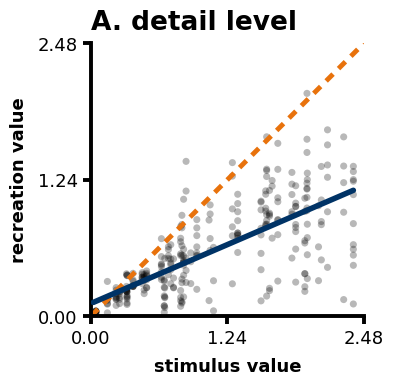

saved: val_r_directionality.png/svg


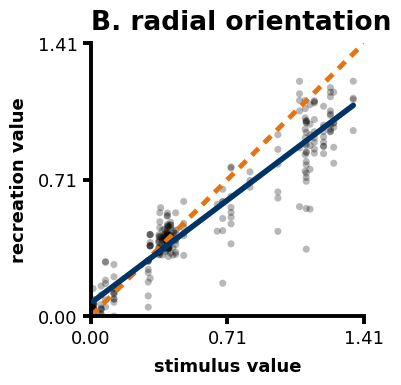

saved: val_theta_directionality.png/svg


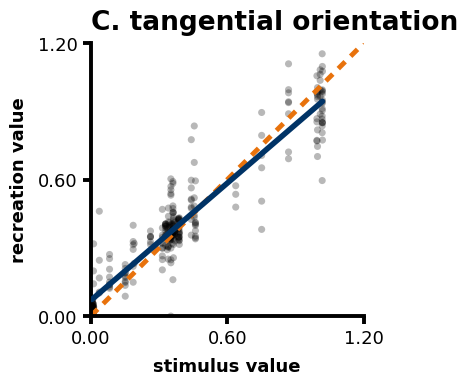

saved: val_brightness.png/svg


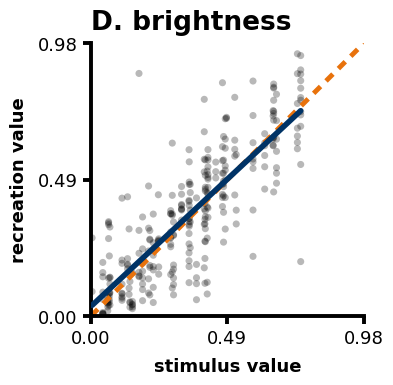

saved: val_contrast.png/svg


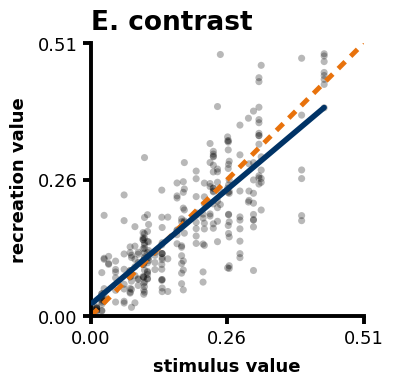

saved: val_key.png/svg


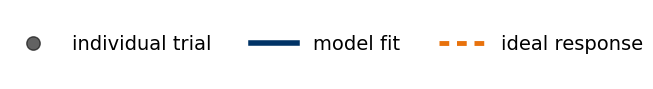

In [6]:
## draw all five panels and the key

for _feature in FEATURES:
    if len(validation_dfs[_feature]):
        plot_validation(_feature, validation_dfs[_feature])

make_validation_key()

## Results table (Table S5.3)

Columns match the supplementary table: variance decomposition rather than the
raw coefficients. `Signal_Val` is the variance of the fitted values (how much
the target explains), `DT` the between-participant variance, `DN` the residual.
The full coefficients (b, SE, z, uncorrected p) are kept in the `_raw.csv`.

In [7]:
# =====================================================================
# TABLE SETTINGS -- adjust these
# =====================================================================

# Which features form the multiple-comparison family. None = every feature in the
# table. Restrict this if the thesis corrects over a subset only.
CORRECTION_FEATURES = None
CORRECTION_METHOD = "holm"

# Decimal places per column of the formatted table.
DECIMALS = {"Signal_Val": 6, "DT": 6, "DN": 6, "b": 6, "se": 6, "z": 2}

# p-values below this print as "< .001"; otherwise 3 decimals with no leading zero.
P_SMALL = 0.001
P_DECIMALS = 3

# ML (reml=False) matches Wald z tests on the fixed effects. Set True for REML,
# which gives less biased variance components but is not comparable across
# different fixed-effect structures.
USE_REML = False

# Column order of the paper-ready table.
PAPER_COLUMNS = ["Feature", "n", "b", "se", "z", "p_holm", "DT", "DN"]
# Add "Signal_Val" back into PAPER_COLUMNS if the fitted-value variance is still
# wanted; add "n_participants" for the participant count.

# Columns for the categorical robustness model (no single slope to report).
CATEGORICAL_COLUMNS = ["Feature", "n", "Chi2", "df", "p_holm", "DT", "DN"]

# Printed header for each raw column name.
COLUMN_LABELS = {
    "b": "b (slope)",
    "se": "SE",
    "z": "z",
    "p_holm": "p (Holm)",
    "p_unc": "p (uncorrected)",
    "DT": "Random-intercept variance",
    "DN": "Residual variance",
    "Signal_Val": "Signal variance",
    "n_participants": "Participants",
}
# =====================================================================


def format_p(p) -> str:
    """'< .001' for very small p, otherwise '.004' style with no leading zero."""
    if pd.isna(p):
        return ""
    if p < P_SMALL:
        return "< " + f"{P_SMALL:.{P_DECIMALS}f}".lstrip("0")
    text = f"{p:.{P_DECIMALS}f}"
    return text.lstrip("0") if text.startswith("0") else text


def format_paper_table(table, columns):
    """Fixed decimals per DECIMALS; p columns via format_p; everything else as-is.

    Every cell is returned as a pre-rounded string, so the printed or displayed
    table can be pasted straight into Google Docs.
    """
    out = pd.DataFrame(index=table.index)
    for col in columns:
        values = table[col]
        if col.startswith("p_") or col.startswith("p ("):
            out[col] = values.map(format_p)
        elif col in DECIMALS:
            out[col] = values.map(
                lambda v: "" if pd.isna(v) else f"{v:.{DECIMALS[col]}f}")
        else:
            out[col] = values
    return out.rename(columns=COLUMN_LABELS)

In [8]:
## fit the confirmatory model: recreation ~ target, random intercept per participant

def fit_validation_model(feature, df):
    """Returns a dict of raw (unformatted) statistics, or None if unfittable."""
    if not check_fittable(feature, df):
        return None

    md, mdf = fit_mixedlm(f"{feature}_rec ~ {feature}_targ", df, reml=USE_REML)
    if mdf is None:
        print(f"  WARNING [{feature}]: every optimiser failed; skipping.")
        return None

    key = f"{feature}_targ"
    dt = float(mdf.cov_re.iloc[0, 0])
    dn = float(mdf.scale)
    if dt < 1e-10:
        print(f"  NOTE [{feature}]: DT ~0 ({dt:.3g}); the participant intercept is "
              f"not identified, so DT and any ICC derived from it are unreliable.")

    return {
        "Experiment": EXPERIMENT_LABEL,
        "Feature": FEATURE_LABELS[feature],
        "_feature_col": feature,
        "n": int(len(df)),
        "Signal_Val": float(np.var(md.predict(mdf.params))),
        "DT": dt,
        "DN": dn,
        "b": float(mdf.params[key]),
        "se": float(mdf.bse[key]),
        "z": float(mdf.tvalues[key]),
        "p_unc": float(mdf.pvalues[key]),
        "n_participants": int(df["participant_code"].nunique()),
    }


rows = [r for r in (fit_validation_model(f, validation_dfs[f]) for f in FEATURES) if r]
validation_raw = pd.DataFrame(rows)
if validation_raw.empty:
    raise ValueError("No feature could be fitted. Check the validation merge in 015.")

family = (validation_raw["_feature_col"].isin(CORRECTION_FEATURES) if CORRECTION_FEATURES
          else pd.Series(True, index=validation_raw.index))
validation_raw["p_holm"] = np.nan
validation_raw.loc[family, "p_holm"] = multipletests(
    validation_raw.loc[family, "p_unc"], alpha=0.05, method=CORRECTION_METHOD)[1]

print(f"\n{CORRECTION_METHOD.title()} correction applied across {int(family.sum())} "
      f"test(s): {', '.join(validation_raw.loc[family, 'Feature'])}")

c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covarianc

  NOTE [r_directionality]: DT ~0 (4.3e-11); the participant intercept is not identified, so DT and any ICC derived from it are unreliable.


c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The


Holm correction applied across 5 test(s): detail level, radial orientation, tangential orientation, brightness, contrast


c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [9]:
## format and export

validation_table = format_paper_table(validation_raw, PAPER_COLUMNS)

validation_raw.drop(columns=["_feature_col"]).to_csv(
    TABLES_PATH / "table_validation_raw.csv", index=False)
validation_table.to_csv(TABLES_PATH / "table_validation.csv", index=False)
validation_table.to_csv(TABLES_PATH / "table_validation.tsv", sep="\t", index=False)

print("Table S5.3 -- validation analysis results")
print("Saved table_validation.csv / .tsv (formatted) and table_validation_raw.csv "
      "(full precision, includes b / se / z / p_unc)\n")
print("Paste-ready (tab separated):\n")
print(validation_table.to_csv(sep="\t", index=False))
display(validation_table)

Table S5.3 -- validation analysis results
Saved table_validation.csv / .tsv (formatted) and table_validation_raw.csv (full precision, includes b / se / z / p_unc)

Paste-ready (tab separated):

Feature	n	b (slope)	SE	z	p (Holm)	Random-intercept variance	Residual variance
detail level	296	0.427464	0.022199	19.26	< .001	0.019314	0.064122
radial orientation	296	0.753533	0.014673	51.35	< .001	0.000000	0.010990
tangential orientation	296	0.859217	0.017720	48.49	< .001	0.000000	0.008976
brightness	296	0.931987	0.037206	25.05	< .001	0.002225	0.015500
contrast	296	0.840334	0.035239	23.85	< .001	0.000422	0.003758



,Feature,n,b (slope),SE,z,p (Holm),Random-intercept variance,Residual variance
0,detail level,296,0.427464,0.022199,19.26,< .001,0.019314,0.064122
1,radial orientation,296,0.753533,0.014673,51.35,< .001,0.000000,0.010990
2,tangential orientation,296,0.859217,0.017720,48.49,< .001,0.000000,0.008976
3,brightness,296,0.931987,0.037206,25.05,< .001,0.002225,0.015500
4,contrast,296,0.840334,0.035239,23.85,< .001,0.000422,0.003758


## Robustness check: categorical model

`recreation ~ C(condition_code)` asks whether target identity matters at all,
without assuming the relationship is linear. Same columns, no figure.

In [10]:
cat_rows = []
for feature in FEATURES:
    df = validation_dfs[feature]
    if df.empty or df["condition_code"].nunique() < 2:
        print(f"  SKIP [{feature}]: fewer than two validation conditions.")
        continue

    md, mdf = fit_mixedlm(f"{feature}_rec ~ C(condition_code)", df, reml=USE_REML)
    if mdf is None:
        print(f"  WARNING [{feature}]: every optimiser failed; skipping.")
        continue

    try:
        t = mdf.wald_test_terms().table
        chi2 = float(np.squeeze(t.loc["C(condition_code)", "statistic"]))
        dfc = int(np.squeeze(t.loc["C(condition_code)", "df_constraint"]))
        p = float(np.squeeze(t.loc["C(condition_code)", "pvalue"]))
    except Exception as e:
        print(f"  WARNING [{feature}]: Wald test failed ({e}); recording NaN.")
        chi2, dfc, p = np.nan, -1, np.nan

    cat_rows.append({
        "Experiment": EXPERIMENT_LABEL,
        "Feature": FEATURE_LABELS[feature],
        "n": int(len(df)),
        "Signal_Val": float(np.var(md.predict(mdf.params))),
        "DT": float(mdf.cov_re.iloc[0, 0]),
        "DN": float(mdf.scale),
        "Chi2": chi2,
        "df": dfc,
        "p_unc": p,
        "n_participants": int(df["participant_code"].nunique()),
    })

categorical_raw = pd.DataFrame(cat_rows)
if not categorical_raw.empty:
    categorical_raw["p_holm"] = multipletests(
        categorical_raw["p_unc"].fillna(1.0), alpha=0.05, method=CORRECTION_METHOD)[1]

    categorical_table = format_paper_table(categorical_raw, CATEGORICAL_COLUMNS)
    categorical_raw.to_csv(TABLES_PATH / "table_validation_categorical_raw.csv", index=False)
    categorical_table.to_csv(TABLES_PATH / "table_validation_categorical.tsv",
                             sep="\t", index=False)
    print("\nPaste-ready (tab separated):\n")
    print(categorical_table.to_csv(sep="\t", index=False))
    display(categorical_table)

c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:1634: UserWarning: Random effects covariance is singular
  warnings.warn(msg)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2054: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2245: UserWarning: The random effects covariance matrix is singular.
  warnings.warn(_warn_cov_sing)
c:\Users\trevo\research\vizex_replication\.venv\Lib\site-packages\statsmodels\base\model.py:1912: FutureWarning: The behavior of wald_test will change aft


Paste-ready (tab separated):

Feature	n	Chi2	df	p (Holm)	Random-intercept variance	Residual variance
detail level	296	719.1405587138399	44	< .001	0.021604	0.039346
radial orientation	296	4049.1419706396277	44	< .001	0.000000	0.007368
tangential orientation	296	3235.236159600856	44	< .001	0.000166	0.006597
brightness	296	1007.3791204147777	44	< .001	0.002928	0.010217
contrast	296	932.4444925258049	44	< .001	0.000425	0.002543



,Feature,n,Chi2,df,p (Holm),Random-intercept variance,Residual variance
0,detail level,296,719.140559,44,< .001,0.021604,0.039346
1,radial orientation,296,4049.141971,44,< .001,0.000000,0.007368
2,tangential orientation,296,3235.236160,44,< .001,0.000166,0.006597
3,brightness,296,1007.379120,44,< .001,0.002928,0.010217
4,contrast,296,932.444493,44,< .001,0.000425,0.002543
